# 第 2 节课 · Notebook 2：MLP 训练 MNIST

## 本 Notebook 目标

完成本 Notebook 后，你将能够：
1. 解释为什么单层感知机不够，需要多层网络
2. 用 PyTorch 搭建一个多层感知机（MLP）
3. 在 MNIST 数据集上训练 MLP，5 个 epoch 达到 95%+ 准确率
4. 理解损失函数、优化器、反向传播的基本作用
5. 画出训练曲线，分析训练过程中的 loss 和准确率变化
6. 理解 MLP 处理图像时的局限性

## 为什么需要多层网络？

上一节我们看到，单层感知机无法解决 XOR 问题，因为 XOR 是线性不可分的。

要解决这个问题，需要两个关键改变：
1. **增加网络的层数**：让网络可以学习更复杂的特征表示
2. **引入非线性激活函数**：让网络可以拟合非线性的决策边界

**多层感知机（Multi-Layer Perceptron, MLP）** 就是在这两个想法基础上发展起来的。

MLP 也叫**全连接神经网络（Fully Connected Neural Network）**，因为它的每一层都和下一层全部相连。


## 0. 环境准备

本 Notebook 需要：
- PyTorch
- torchvision（用于加载 MNIST）
- matplotlib（用于画图）
- numpy

如果第一节课的环境已经配好，这些库应该都已经安装。如果没有，运行：

```bash
pip install torch torchvision matplotlib numpy
```


In [2]:
# 导入必要的库
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 自动选择计算设备
# 优先使用 GPU（CUDA），其次是 MPS（Apple Silicon），最后是 CPU
device = torch.device('cuda' if torch.cuda.is_available() else
                     'mps' if torch.backends.mps.is_available() else
                     'cpu')
print(f"使用设备: {device}")


使用设备: cuda


## 1. 认识 MNIST 数据集

MNIST 是深度学习领域最著名的入门数据集之一，包含：
- 训练集：60,000 张手写数字图片
- 测试集：10,000 张手写数字图片
- 图片尺寸：28 × 28 像素，灰度图
- 类别数：10（数字 0-9）

这个数据集相对简单，适合用来验证我们的第一个神经网络。


In [3]:
# 定义数据预处理流程
# transforms.ToTensor()：把 PIL Image 转成 PyTorch Tensor，并把像素值从 [0, 255] 缩放到 [0, 1]
# transforms.Normalize(...)：用均值和标准差做标准化，让数据分布更稳定
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST 数据集的标准化参数
])

# 加载 MNIST 数据集
# 首次运行会自动下载到 ./data 目录，大约 50MB
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

# DataLoader 用于批量加载数据
# batch_size=64：每次取 64 张图片一起训练
# shuffle=True：每个 epoch 打乱训练数据顺序，防止模型记忆顺序
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False, num_workers=0)

print(f"训练集样本数: {len(train_dataset):,}")
print(f"测试集样本数: {len(test_dataset):,}")
print(f"每张图片尺寸: 28 × 28 = 784 像素")
print(f"训练 batch 数: {len(train_loader)}")


训练集样本数: 60,000
测试集样本数: 10,000
每张图片尺寸: 28 × 28 = 784 像素
训练 batch 数: 938


### 1.1 可视化部分训练样本

我们先看看数据长什么样。


findfont: Failed to find font weight bold, now using 400.


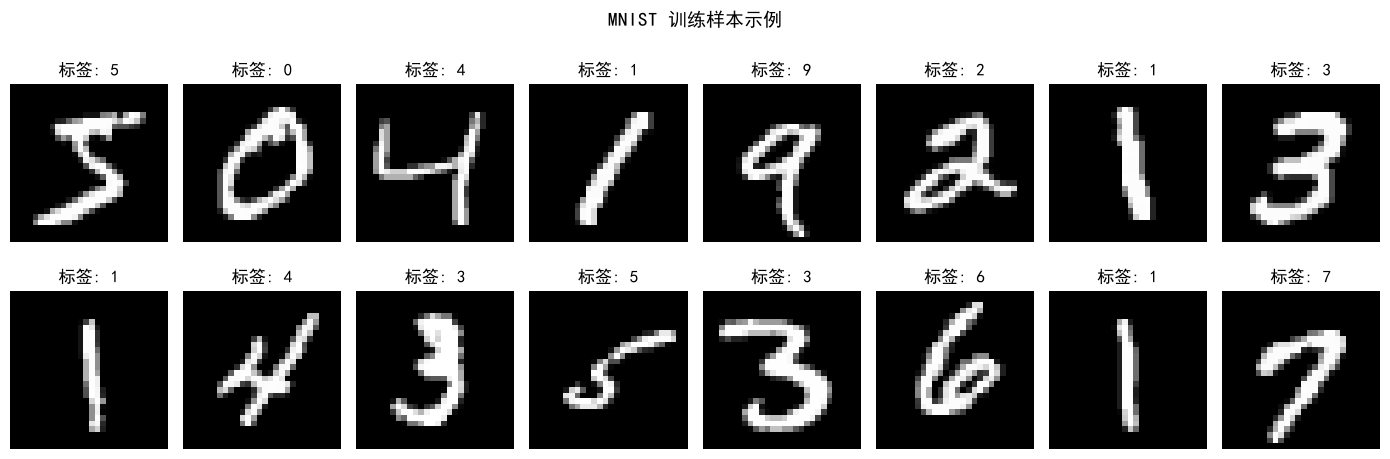

In [4]:
# 创建一个 2×8 的子图，展示 16 张训练样本
fig, axes = plt.subplots(2, 8, figsize=(14, 5))

for i, ax in enumerate(axes.flat):
    # 获取第 i 张图片和标签
    img, label = train_dataset[i]

    # img 的形状是 (1, 28, 28)，需要 squeeze 成 (28, 28)
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"标签: {label}")
    ax.axis('off')

plt.suptitle("MNIST 训练样本示例", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 2. 定义 MLP 模型

### 2.1 网络结构

我们构建的 MLP 结构如下：

```
输入层：784 个神经元（28×28 展平）
    ↓
隐藏层 1：256 个神经元 + ReLU 激活
    ↓
隐藏层 2：128 个神经元 + ReLU 激活
    ↓
输出层：10 个神经元（对应 10 个数字类别）
```

### 2.2 为什么需要激活函数？

如果没有激活函数，多层网络就等价于一层线性变换：

$$\text{Layer2}(\text{Layer1}(x)) = W_2 (W_1 x + b_1) + b_2 = (W_2 W_1) x + (W_2 b_1 + b_2)$$

无论多少层，结果都是线性的，解决不了 XOR 这类非线性问题。

激活函数（如 ReLU）引入了非线性：

$$\text{ReLU}(z) = \max(0, z)$$

这样网络就可以拟合复杂的非线性决策边界。

### 2.3 参数量计算

- fc1: $784 \times 256 + 256 = 200,960$
- fc2: $256 \times 128 + 128 = 32,896$
- fc3: $128 \times 10 + 10 = 1,290$
- **总计：235,146**


In [5]:
class MLP(nn.Module):
    """
    多层感知机（MLP）用于 MNIST 手写数字分类。

    结构: 784 -> 256 -> 128 -> 10
    """
    def __init__(self):
        super().__init__()
        # 第一层全连接：输入 784，输出 256
        self.fc1 = nn.Linear(28 * 28, 256)
        # 第二层全连接：输入 256，输出 128
        self.fc2 = nn.Linear(256, 128)
        # 第三层全连接：输入 128，输出 10（类别数）
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        # x 的原始形状是 [batch_size, 1, 28, 28]
        # 需要展平成 [batch_size, 784]
        x = x.view(x.size(0), -1)

        # 第一层 + ReLU 激活
        x = F.relu(self.fc1(x))

        # 第二层 + ReLU 激活
        x = F.relu(self.fc2(x))

        # 第三层：输出 logits
        # 注意：这里没有 softmax，因为 CrossEntropyLoss 内部会帮我们做 softmax
        x = self.fc3(x)

        return x


# 创建模型并移动到设备上
model = MLP().to(device)

# 统计参数量
total_params = sum(p.numel() for p in model.parameters())
print(f"MLP 总参数量: {total_params:,}")
print("\n逐层参数:")
for name, param in model.named_parameters():
    print(f"  {name:<15} shape={str(tuple(param.shape)):<15} params={param.numel():>8,}")


MLP 总参数量: 235,146

逐层参数:
  fc1.weight      shape=(256, 784)      params= 200,704
  fc1.bias        shape=(256,)          params=     256
  fc2.weight      shape=(128, 256)      params=  32,768
  fc2.bias        shape=(128,)          params=     128
  fc3.weight      shape=(10, 128)       params=   1,280
  fc3.bias        shape=(10,)           params=      10


## 3. 损失函数和优化器

### 3.1 损失函数：交叉熵损失（CrossEntropyLoss）

对于分类问题，我们常用**交叉熵损失**：

$$L = -\sum_{i} y_i \log(\hat{y}_i)$$

其中：
- $y_i$ 是真实标签的 one-hot 编码
- $\hat{y}_i$ 是模型预测的概率（通过 softmax 得到）

在 PyTorch 中，`nn.CrossEntropyLoss()` 把 **softmax + 负对数似然** 合并在一起了，所以模型输出层直接输出 logits 即可。

### 3.2 优化器：带动量的 SGD

**随机梯度下降（SGD）**的更新公式：

$$\theta = \theta - \eta \nabla_\theta L$$

**带动量的 SGD** 增加了"惯性"：

$$v_t = \beta v_{t-1} + \nabla_\theta L$$

$$\theta = \theta - \eta v_t$$

动量项 $\beta$ 通常是 0.9。它的作用是：
- 在梯度方向一致时加速
- 在梯度方向震荡时抑制抖动
- 帮助跳出局部最优


In [6]:
# 定义损失函数：交叉熵损失
# 它内部包含 softmax，所以模型输出 logits 即可
criterion = nn.CrossEntropyLoss()

# 定义优化器：带动量的 SGD
# lr=0.01 是学习率
# momentum=0.9 是动量系数
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

print("损失函数: CrossEntropyLoss")
print("优化器: SGD with momentum=0.9, lr=0.01")


损失函数: CrossEntropyLoss
优化器: SGD with momentum=0.9, lr=0.01


## 4. 训练循环

训练一个神经网络通常包括以下步骤：

1. **前向传播（Forward）**：把输入数据送入模型，得到预测输出
2. **计算损失（Loss）**：比较预测输出和真实标签
3. **反向传播（Backward）**：计算损失对每个参数的梯度
4. **更新参数（Step）**：用优化器根据梯度更新参数

这四个步骤会在每个 batch 上重复执行，直到遍历完整个训练集（称为一个 **epoch**）。


In [7]:
def train(model, train_loader, test_loader, epochs=5, lr=0.01):
    """
    训练模型并返回训练历史。

    参数:
        model: 要训练的 PyTorch 模型
        train_loader: 训练数据加载器
        test_loader: 测试数据加载器
        epochs: 训练轮数
        lr: 学习率
    返回:
        history: 包含 train_loss, train_acc, test_acc 的字典
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

    print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Test Acc':<12}")
    print("-" * 50)

    for epoch in range(1, epochs + 1):
        # ---------- 训练阶段 ----------
        model.train()  # 设置为训练模式（启用 dropout、batchnorm 等）
        train_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            # 把数据移动到设备上
            images, labels = images.to(device), labels.to(device)

            # 1. 清空旧梯度
            optimizer.zero_grad()

            # 2. 前向传播
            outputs = model(images)

            # 3. 计算损失
            loss = criterion(outputs, labels)

            # 4. 反向传播
            loss.backward()

            # 5. 更新参数
            optimizer.step()

            # 统计训练指标
            train_loss += loss.item()
            _, predicted = outputs.max(1)  # 取概率最大的类别作为预测
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        # 计算本轮平均训练损失和准确率
        train_acc = 100. * correct / total
        train_loss /= len(train_loader)

        # ---------- 测试阶段 ----------
        model.eval()  # 设置为评估模式
        test_correct = 0
        test_total = 0

        # 测试时不需要计算梯度，用 torch.no_grad() 加速
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()

        test_acc = 100. * test_correct / test_total

        # 记录历史
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        print(f"{epoch:<8} {train_loss:<12.4f} {train_acc:<12.2f}% {test_acc:<12.2f}%")

    return history


# 开始训练
history = train(model, train_loader, test_loader, epochs=5, lr=0.01)
print(f"\n✅ 最终测试准确率: {history['test_acc'][-1]:.2f}%")


Epoch    Train Loss   Train Acc    Test Acc    
--------------------------------------------------
1        0.3093       90.79       % 95.79       %
2        0.1048       96.85       % 97.22       %
3        0.0694       97.89       % 97.02       %
4        0.0521       98.40       % 97.74       %
5        0.0378       98.83       % 97.78       %

✅ 最终测试准确率: 97.78%


## 5. 可视化训练曲线

训练曲线是诊断模型训练过程的重要工具：
- **Loss 曲线**：应该逐渐下降
- **Train/Test 准确率**：应该逐渐上升
- 如果 train acc 远高于 test acc，说明可能过拟合了


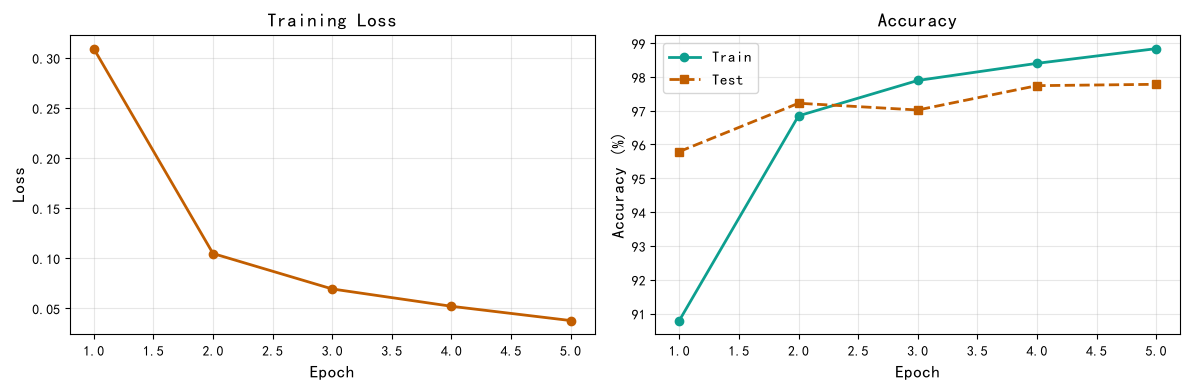

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = list(range(1, len(history['train_loss']) + 1))

# 左图：Loss 曲线
axes[0].plot(epochs, history['train_loss'], 'o-', color='#c25e00', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# 右图：准确率曲线
axes[1].plot(epochs, history['train_acc'], 'o-', color='#0d9f8f', linewidth=2, label='Train')
axes[1].plot(epochs, history['test_acc'], 's--', color='#c25e00', linewidth=2, label='Test')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. 错误案例分析

看看模型在哪些样本上犯了错，能帮助我们理解模型的弱点。


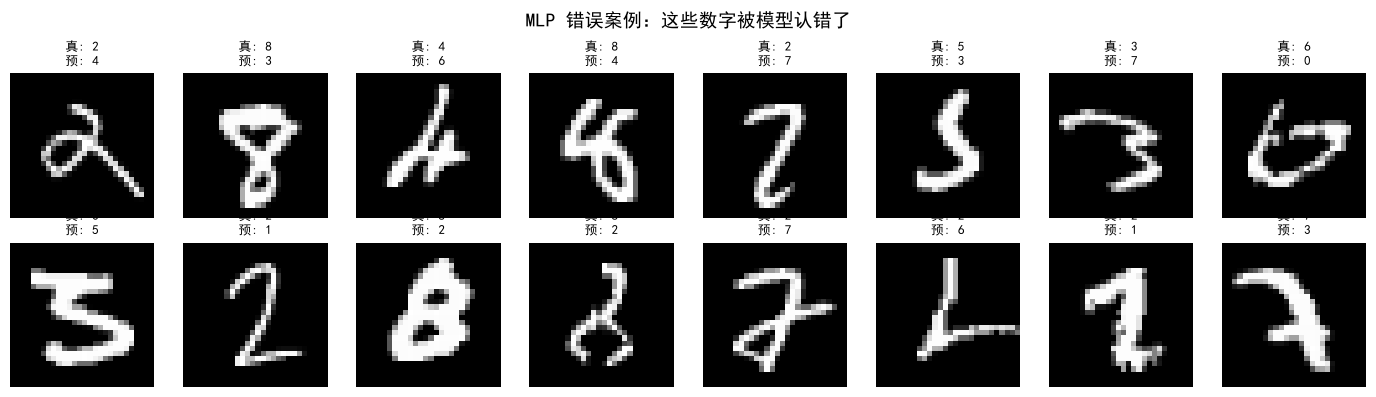

In [9]:
model.eval()
wrong_images = []
wrong_labels = []
wrong_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        mask = predicted != labels  # 找出预测错误的样本
        wrong_images.extend(images[mask].cpu())
        wrong_labels.extend(labels[mask].cpu().numpy())
        wrong_preds.extend(predicted[mask].cpu().numpy())
        if len(wrong_images) >= 16:
            break

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    if i < len(wrong_images):
        ax.imshow(wrong_images[i].squeeze(), cmap='gray')
        ax.set_title(f"真: {wrong_labels[i]}\n预: {wrong_preds[i]}", fontsize=9)
    ax.axis('off')

plt.suptitle("MLP 错误案例：这些数字被模型认错了", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. 数学穿插：梯度检查

反向传播（Backpropagation）的核心是**链式法则**。PyTorch 的 `autograd` 会自动帮我们计算梯度。

下面我们打印每个参数的梯度大小，看看训练时梯度长什么样。


In [10]:
model.train()

# 取一个 batch 的数据
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

# 前向传播
outputs = model(images)
loss = F.cross_entropy(outputs, labels)

# 反向传播：计算梯度
loss.backward()

print(f"{'Layer':<20} {'Shape':<20} {'grad_mean':<12} {'grad_max':<12}")
print("-" * 70)
for name, param in model.named_parameters():
    if param.grad is not None:
        g_mean = param.grad.abs().mean().item()
        g_max = param.grad.abs().max().item()
        print(f"{name:<20} {str(tuple(param.shape)):<20} {g_mean:<12.6f} {g_max:<12.6f}")

print("\n💡 链式法则: ∂L/∂w = ∂L/∂y × ∂y/∂z × ∂z/∂w")
print("💡 PyTorch 的 autograd 自动完成了这些计算")


Layer                Shape                grad_mean    grad_max    
----------------------------------------------------------------------
fc1.weight           (256, 784)           0.001575     0.046215    
fc1.bias             (256,)               0.002011     0.012775    
fc2.weight           (128, 256)           0.001716     0.047822    
fc2.bias             (128,)               0.002423     0.009624    
fc3.weight           (10, 128)            0.004681     0.090727    
fc3.bias             (10,)                0.004986     0.023509    

💡 链式法则: ∂L/∂w = ∂L/∂y × ∂y/∂z × ∂z/∂w
💡 PyTorch 的 autograd 自动完成了这些计算


## 8. MLP 的局限性

MLP 虽然能完成 MNIST 分类，但它有一个明显的问题：

**把 28×28 的图片展平成 784 维向量，完全忽略了像素之间的空间关系。**

例如：
- 图片中相邻的像素在空间上是相关的
- 一个数字的笔画具有局部结构
- MLP 把所有像素同等对待，没有利用这些先验知识

这就好比把一幅画剪成碎片，然后随机排列后让模型学习。模型需要额外学习"哪些像素在原始图片中是相邻的"。

下一节我们将学习 **卷积神经网络（CNN）**，它专门利用图像的空间结构，用更少的参数达到更好的效果。


## 9. 动手练习

### 练习 1：改变隐藏层大小
尝试把隐藏层改成 `[512, 256]` 或 `[128, 64]`，观察：
- 参数量变化多少？
- 训练速度变化？
- 最终准确率变化？

### 练习 2：换激活函数
把 `F.relu` 换成 `F.sigmoid` 或 `F.tanh`，看看训练还快吗？为什么？

### 练习 3：增加训练轮数
把 epochs 从 5 增加到 10 或 20，观察 train acc 和 test acc 的差距是否变大（过拟合）。

### 练习 4：换优化器
把 SGD 换成 Adam，观察收敛速度和最终效果。


## 10. 常见问题

**Q1：为什么输出层不加 softmax？**

A：`nn.CrossEntropyLoss()` 内部已经包含了 softmax。如果输出层再加 softmax，就成了对概率取 log，会出错。

**Q2：为什么要用 `model.train()` 和 `model.eval()`？**

A：`train()` 会启用 dropout、batchnorm 的训练行为；`eval()` 会关闭这些，用于评估。对于 MLP 来说影响不大，但养成习惯很重要。

**Q3：为什么 test acc 比 train acc 低？**

A：模型在训练数据上学习，多少会记忆一些训练样本的特征。测试集是模型没见过的数据，所以准确率通常会低一点。如果差距太大，就是过拟合。


## 11. 小结

- **MLP = 多层全连接网络 + 非线性激活函数**
- ReLU 等激活函数让网络可以学习非线性决策边界
- 训练流程：前向传播 → 计算损失 → 反向传播 → 更新参数
- 在 MNIST 上，MLP 5 epochs 可以达到 95%+
- MLP 的局限：忽略图片空间结构，参数量较大

下一节我们将学习 CNN，看看如何利用空间结构进一步提升效果。
